In [1]:
# Tasks:

#     Data Import and Cleaning:
#         Import the dataset using Pandas.
#         Identify missing values and handle them appropriately.
#         Use NumPy to convert relevant columns to numerical types if necessary.

#     Exploratory Data Analysis:
#         Utilize Pandas to summarize key statistics (mean, median, standard deviation) for numerical columns.
#         Explore the distribution of power plants by country and fuel type.

#     Statistical Analysis:
#         Perform a statistical analysis of power output by fuel type using NumPy’s statistical functions.
#         Use hypothesis testing to determine if the mean power output differs significantly between different fuel types.

#     Time Series Analysis:
#         If the dataset includes time-related data (like year of establishment), use NumPy to analyze trends over time.
#         Explore how the mix of fuel types for power generation has evolved over the years.

#     Advanced Visualization:
#         Create visualizations using Matplotlib and Seaborn to illustrate your findings.
#         Consider plotting the geographical distribution of power plants using latitude and longitude data, if available.

#     Matrix Operations in Real-World Context:
#         Demonstrate matrix operations by analyzing relationships between different attributes (e.g., fuel type, capacity, and geographic location).
#         Discuss the relevance of eigenvectors and eigenvalues in this context.

#     Integrating NumPy with Pandas and Matplotlib:
#         Show how NumPy can be used to enhance data manipulation in Pandas and data visualization in Matplotlib.
#         Provide examples, such as using NumPy arrays for complex filtering in Pandas or for creating sophisticated plots in Matplotlib.

# Submit your Daily Challenge

# Prepare a report including your code, findings, and visualizations. Discuss how NumPy, Pandas, and Matplotlib were used in your analysis, and present any interesting insights you discovered about the global power plant landscape.

In [2]:
#     Data Import and Cleaning:
#         Import the dataset using Pandas.
#         Identify missing values and handle them appropriately.
#         Use NumPy to convert relevant columns to numerical types if necessary.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_raw = pd.read_csv('global_power_plant_database.csv')
df = df_raw.copy()
df.head()

C:\Users\benbo\AppData\Local\Temp\ipykernel_35428\2749004223.py:9: DtypeWarning: Columns (0: other_fuel3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv('global_power_plant_database.csv')


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


In [3]:
df.shape

(34936, 36)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34936 non-null  str    
 1   country_long                    34936 non-null  str    
 2   name                            34936 non-null  str    
 3   gppd_idnr                       34936 non-null  str    
 4   capacity_mw                     34936 non-null  float64
 5   latitude                        34936 non-null  float64
 6   longitude                       34936 non-null  float64
 7   primary_fuel                    34936 non-null  str    
 8   other_fuel1                     1944 non-null   str    
 9   other_fuel2                     276 non-null    str    
 10  other_fuel3                     92 non-null     str    
 11  commissioning_year              17447 non-null  float64
 12  owner                           20868 non-n

In [5]:
df.describe()

,capacity_mw,latitude,longitude,commissioning_year,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,generation_gwh_2017,generation_gwh_2018,generation_gwh_2019,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017
count,34936.000000,34936.000000,34936.000000,17447.000000,14887.000000,6417.000000,7226.000000,8203.000000,9144.000000,9500.000000,9637.000000,9659.000000,16120.000000,16503.000000,17050.000000,17570.000000,33138.000000
mean,163.355148,32.816637,-6.972803,1997.414823,2018.218849,592.696107,656.863891,762.368840,693.149763,661.834161,517.320785,423.922436,239.112221,242.431122,235.866067,235.695265,716.443378
std,489.636072,22.638603,78.405850,23.397835,1.606428,2174.833482,2231.464288,2533.459828,2404.516759,2369.296957,1975.302686,1698.506485,1191.258172,1285.798297,1267.005223,1259.559841,2484.361200
min,1.000000,-77.847000,-179.977700,1896.000000,2000.000000,-947.600000,-989.619000,-864.428000,-768.620000,-934.944000,-982.622000,-780.339000,1.120000,0.870000,0.440000,0.300000,0.000000
25%,4.900000,29.256475,-77.641550,1988.000000,2017.000000,1.947000,2.260000,2.664500,2.729000,2.467000,2.242000,2.751500,8.620000,8.680000,8.380000,8.322500,8.180000
50%,16.745000,39.727750,-2.127100,2007.000000,2019.000000,23.426000,23.608500,26.142000,22.462389,17.876500,12.530000,11.530000,27.620000,28.250000,26.830000,27.555000,37.590000
75%,75.344250,46.263125,49.502675,2014.000000,2019.000000,199.706000,226.322250,285.862583,249.866750,214.505150,151.117000,122.781498,106.805000,106.980000,103.120000,107.237500,229.565000
max,22500.000000,71.292000,179.388700,2020.000000,2019.000000,50834.000000,32320.917000,37433.607000,32377.477000,36448.643000,35136.000000,31920.368000,48675.060000,58470.770000,57113.350000,60859.730000,82810.770000


In [6]:
df.columns

Index(['country', 'country_long', 'name', 'gppd_idnr', 'capacity_mw',
       'latitude', 'longitude', 'primary_fuel', 'other_fuel1', 'other_fuel2',
       'other_fuel3', 'commissioning_year', 'owner', 'source', 'url',
       'geolocation_source', 'wepp_id', 'year_of_capacity_data',
       'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015',
       'generation_gwh_2016', 'generation_gwh_2017', 'generation_gwh_2018',
       'generation_gwh_2019', 'generation_data_source',
       'estimated_generation_gwh_2013', 'estimated_generation_gwh_2014',
       'estimated_generation_gwh_2015', 'estimated_generation_gwh_2016',
       'estimated_generation_gwh_2017', 'estimated_generation_note_2013',
       'estimated_generation_note_2014', 'estimated_generation_note_2015',
       'estimated_generation_note_2016', 'estimated_generation_note_2017'],
      dtype='str')

In [7]:
df.isna().sum()

country                               0
country_long                          0
name                                  0
gppd_idnr                             0
capacity_mw                           0
latitude                              0
longitude                             0
primary_fuel                          0
other_fuel1                       32992
other_fuel2                       34660
other_fuel3                       34844
commissioning_year                17489
owner                             14068
source                               15
url                                  18
geolocation_source                  419
wepp_id                           18702
year_of_capacity_data             20049
generation_gwh_2013               28519
generation_gwh_2014               27710
generation_gwh_2015               26733
generation_gwh_2016               25792
generation_gwh_2017               25436
generation_gwh_2018               25299
generation_gwh_2019               25277


In [8]:
###To remove columns with over 50% of rows empty, we would do the following:
#########
# # Calculate the minimum number of non-empty cells required (50% of total rows)
# limit = len(df) * 0.5

# # dropna(axis=1) targets columns
# # thresh=limit keeps columns that have AT LEAST 50% non-empty values
# df = df.dropna(axis=1, thresh=limit)
# df.isna().sum()
#########
###BUT: That would remove all the data regarding fuel generation(all the columns with fuel generation data). So that doesn't make sense to do. Instead, we can hold off on dealing with empty cells and remove empty rows or columns as needed in connection with each task.

In [9]:
##To remove rows with missing columns for columns where less than 5% is missing we would do the following.
# But in this case we will hold off until we need those columns, so we can have as much data as possible for other analyses.

# for col in df.columns:
#     missing_ratio = df[col].isnull().mean()
    
#     # If the "hole" in the data is small (between 0% and 5%)
#     if 0 < missing_ratio < 0.05:
#         df = df.dropna(subset=[col])
# df.isna().sum()


In [11]:
#         Use NumPy to convert relevant columns to numerical types if necessary.
# There don't seem to be any columns that should be made numerical now.
# Utilize Pandas to summarize key statistics (mean, median, standard deviation) for numerical columns.
df.describe()

,capacity_mw,latitude,longitude,commissioning_year,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,generation_gwh_2017,generation_gwh_2018,generation_gwh_2019,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017
count,34936.000000,34936.000000,34936.000000,17447.000000,14887.000000,6417.000000,7226.000000,8203.000000,9144.000000,9500.000000,9637.000000,9659.000000,16120.000000,16503.000000,17050.000000,17570.000000,33138.000000
mean,163.355148,32.816637,-6.972803,1997.414823,2018.218849,592.696107,656.863891,762.368840,693.149763,661.834161,517.320785,423.922436,239.112221,242.431122,235.866067,235.695265,716.443378
std,489.636072,22.638603,78.405850,23.397835,1.606428,2174.833482,2231.464288,2533.459828,2404.516759,2369.296957,1975.302686,1698.506485,1191.258172,1285.798297,1267.005223,1259.559841,2484.361200
min,1.000000,-77.847000,-179.977700,1896.000000,2000.000000,-947.600000,-989.619000,-864.428000,-768.620000,-934.944000,-982.622000,-780.339000,1.120000,0.870000,0.440000,0.300000,0.000000
25%,4.900000,29.256475,-77.641550,1988.000000,2017.000000,1.947000,2.260000,2.664500,2.729000,2.467000,2.242000,2.751500,8.620000,8.680000,8.380000,8.322500,8.180000
50%,16.745000,39.727750,-2.127100,2007.000000,2019.000000,23.426000,23.608500,26.142000,22.462389,17.876500,12.530000,11.530000,27.620000,28.250000,26.830000,27.555000,37.590000
75%,75.344250,46.263125,49.502675,2014.000000,2019.000000,199.706000,226.322250,285.862583,249.866750,214.505150,151.117000,122.781498,106.805000,106.980000,103.120000,107.237500,229.565000
max,22500.000000,71.292000,179.388700,2020.000000,2019.000000,50834.000000,32320.917000,37433.607000,32377.477000,36448.643000,35136.000000,31920.368000,48675.060000,58470.770000,57113.350000,60859.730000,82810.770000


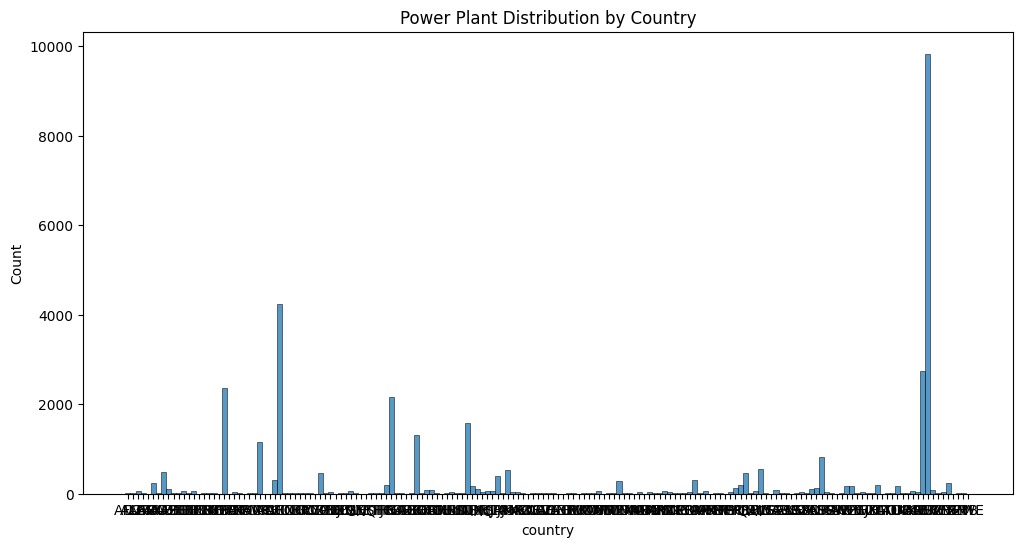

In [28]:
#Explore the distribution of power plants by country and fuel type.
#So we create histograms:
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='country')
plt.title('Power Plant Distribution by Country')
plt.show()

In [19]:
# There are so many countries that it's hard to even view the country labels. But we can see that there are many countries with very few power plants, a handful with a bunch (500 to 4500) and one with a huge number. Which country is that?
df['country_long'].value_counts()

country_long
United States of America    9833
China                       4235
United Kingdom              2751
Brazil                      2360
France                      2155
                            ... 
Lesotho                        1
Palestine                      1
Saint Lucia                    1
Suriname                       1
Western Sahara                 1
Name: count, Length: 167, dtype: int64

In [25]:
# It is the USA.

#Explore the distribution of power plants by fuel type:
df['primary_fuel'].value_counts()

primary_fuel
Solar             10665
Hydro              7156
Wind               5344
Gas                3998
Coal               2330
Oil                2320
Biomass            1430
Waste              1068
Nuclear             195
Geothermal          189
Storage             135
Other                43
Cogeneration         41
Petcoke              12
Wave and Tidal       10
Name: count, dtype: int64

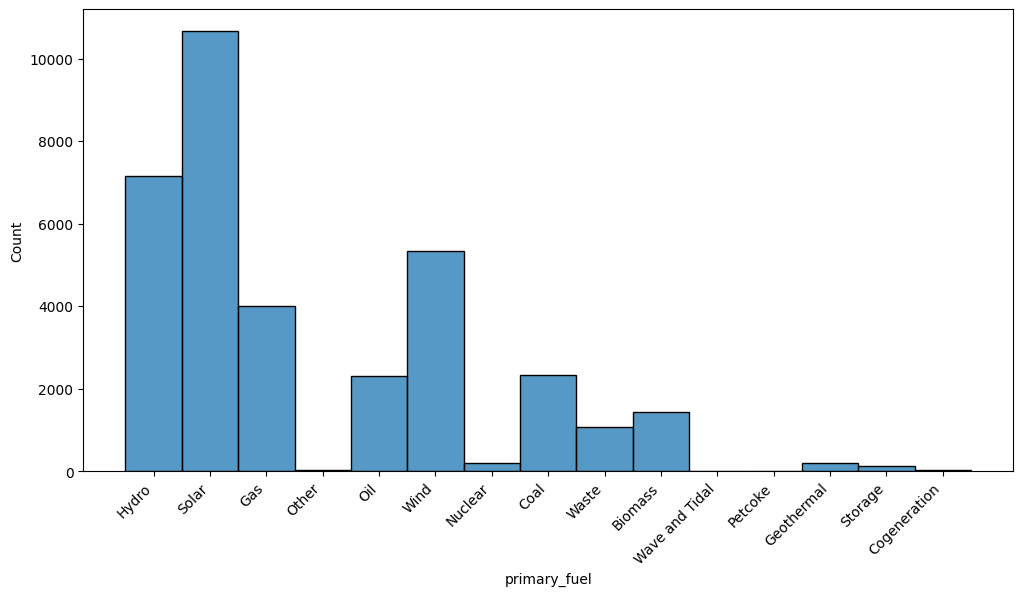

In [30]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='primary_fuel')
plt.xticks(rotation=45, ha='right')
plt.show()

In [82]:
## We see that the largest type of plants is solar, followed by hydro and wind, whereas other categories known to be large energy sources such as gas, oil, coal, and nuclear, have fewer plants. We might guess that these renewable plants that are more numerous produce less energy, while the fossil fuel and nuclear plants each produce more energy per plant than them. This is something we can examine if of interest.

# Statistical Analysis:

#     Perform a statistical analysis of power output by fuel type using NumPy’s statistical functions.
# Since we will be looking at power output, let's create a new df where we will remove the rows without power output data.
df1 = df.copy()
generation_list = ['generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015', 'generation_gwh_2016', 'generation_gwh_2017', 'generation_gwh_2018', 'generation_gwh_2019']
df1=df1.dropna(subset=generation_list)
generation_stats = df1.groupby('primary_fuel')[generation_list].agg(['sum', 'mean', 'median','count'])
total_sums = generation_stats.xs('sum', axis=1, level=1).sum(axis=1)
total_means = generation_stats.xs('mean', axis=1, level=1).sum(axis=1)
generation_stats['total_sums'] = total_sums
generation_stats['total_means'] = total_means
generation_stats_sorted = generation_stats.loc[total_sums.sort_values(ascending=False).index]
generation_stats_sorted
## Insights here: The largest fuels in terms of total production are Gas, Coal, Nuclear, etc. respectively. However, coal and nuclear plants each generally produce more power: their median generation is much higher; nuclear has the highest median power generation.

generation_gwh_2013                                    \
                             sum          mean        median count   
primary_fuel                                                         
Gas                 1.050609e+06    691.190067     41.911500  1520   
Coal                1.104642e+06   3931.110328   2470.211954   281   
Nuclear             7.733500e+05  13333.621024  14181.163500    58   
Hydro               2.624237e+05    192.251809     24.599000  1365   
Wind                1.655676e+05    215.863840    138.481000   767   
Waste               3.578208e+04     80.772183     32.871000   443   
Biomass             2.189292e+04    179.450190     44.628963   122   
Geothermal          1.517983e+04    261.721122    129.643850    58   
Solar               8.698973e+03     14.214008      2.776545   612   
Oil                 1.037671e+04     13.854090      0.059000   749   
Petcoke             9.440433e+03    944.043346     80.018690    10   
Cogeneration        3.593916e+03    133.108012     41.238000    27   
Other               1.225344e+03     94.257235     43.791620    13   
Storage             2.660058e+03    532.011599      6.026000     5   

             generation_gwh_2014                                    \
                             sum          mean        median count   
primary_fuel                                                         
Gas                 1.016043e+06    668.449211     36.540000  1520   
Coal                1.098811e+06   3910.358747   2295.855000   281   
Nuclear             7.762987e+05  13384.459982  14491.824000    58   
Hydro               2.520806e+05    184.674425     22.880000  1365   
Wind                1.751275e+05    228.327848    148.962000   767   
Waste               3.776111e+04     85.239537     34.414000   443   
Biomass             2.149533e+04    176.191208     43.604720   122   
Geothermal          1.542845e+04    266.007759    137.942000    58   
Solar               1.441289e+04     23.550480      3.891500   612   
Oil                 1.167062e+04     15.581602      0.064000   749   
Petcoke             8.298018e+03    829.801779    101.601435    10   
Cogeneration        3.155794e+03    116.881276     38.997000    27   
Other               1.111788e+03     85.522165     42.002940    13   
Storage             1.656478e+03    331.295592      5.364000     5   

             generation_gwh_2015                ... generation_gwh_2018  \
                             sum          mean  ...                 sum   
primary_fuel                                    ...                       
Gas                 1.176142e+06    773.777312  ...        1.120172e+06   
Coal                1.023115e+06   3640.979072  ...        8.729234e+05   
Nuclear             7.840980e+05  13518.930587  ...        7.925642e+05   
Hydro               2.425679e+05    177.705442  ...        2.835086e+05   
Wind                1.627853e+05    212.236336  ...        1.611119e+05   
Waste               3.670051e+04     82.845397  ...        3.458612e+04   
Biomass             2.256629e+04    184.969618  ...        2.025025e+04   
Geothermal          1.553328e+04    267.815138  ...        1.546030e+04   
Solar               1.578563e+04     25.793512  ...        1.538042e+04   
Oil                 8.173445e+03     10.912476  ...        7.150938e+03   
Petcoke             7.614146e+03    761.414599  ...        8.313174e+03   
Cogeneration        3.082669e+03    114.172928  ...        2.554506e+03   
Other               1.158452e+03     89.111659  ...        1.366020e+03   
Storage             1.088330e+02     21.766600  ...       -6.520000e+00   

                                               generation_gwh_2019  \
                      mean        median count                 sum   
primary_fuel                                                         
Gas             736.955478     41.449045  1520        1.359528e+06   
Coal           3106.489081   1256.641985   281        9.377848e+05   
Nucle

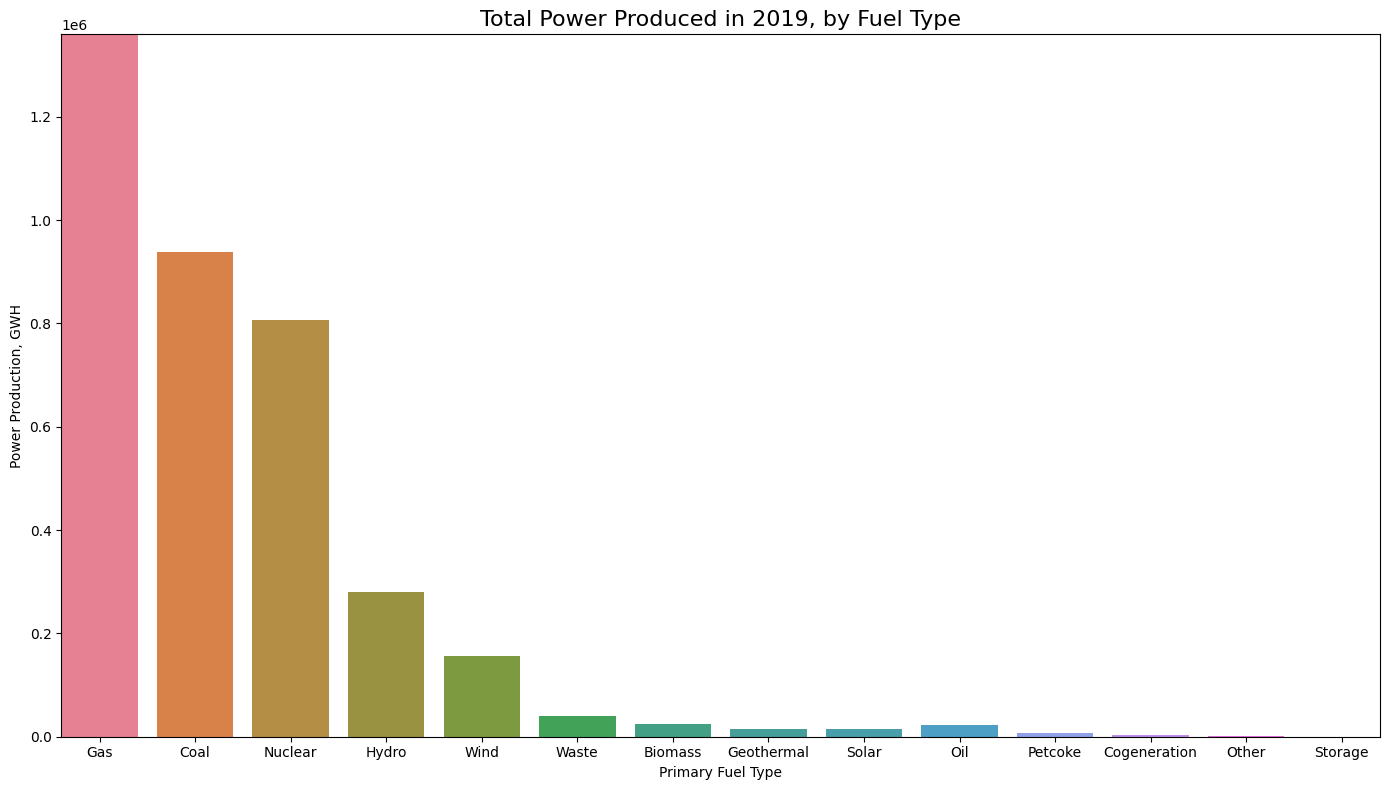

In [92]:
#Let's create a visualization of the total power generated in 2019 by fuel type:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.barplot(data=generation_stats_sorted, x = 'primary_fuel',y = ('generation_gwh_2019', 'sum'),
            hue='primary_fuel')


plt.title('Total Power Produced in 2019, by Fuel Type', fontsize=16)
plt.ylabel('Power Production, GWH')
plt.xlabel('Primary Fuel Type')
plt.margins(0, 0) # Remove white space at edges
plt.tight_layout()
plt.show()

In [61]:
# Use hypothesis testing to determine if the mean power output differs significantly between different fuel types.
#To do so we will use One-Way ANOVA.
from scipy import stats
df1['total_gen_raw'] = df1[generation_list].sum(axis=1)


# 1. Create a list of arrays, one for each fuel type
fuel_groups = [group['total_gen_raw'].dropna() for name, group in df1.groupby('primary_fuel')]

# 2. Run the ANOVA
f_stat, p_val = stats.f_oneway(*fuel_groups)

print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_val:.4e}")

if p_val < 0.05:
    print("Significant difference found: At least one fuel type has a different mean.")
else:
    print("No significant difference found.")

F-Statistic: 541.3100
P-Value: 0.0000e+00
Significant difference found: At least one fuel type has a different mean.


In [68]:
# Time Series Analysis:

#     If the dataset includes time-related data (like year of establishment), use NumPy to analyze trends over time.
#     Explore how the mix of fuel types for power generation has evolved over the years.
#One analysis: analysis of the mix of power plant types has evolved over the years, based on year of establishment.
# For this analysis we will need a dataset with primary_fuel and commissioning_year.
df2 = df[['name','primary_fuel','commissioning_year']]
df2=df2.dropna(subset=['primary_fuel','commissioning_year'])


# 1. Create a 'Decade' column
df2['decade'] = (df2['commissioning_year'] // 10 * 10).astype(int)

# 2. Count occurrences of each fuel per decade
evolution = df2.groupby(['decade', 'primary_fuel']).size().unstack(fill_value=0)

# 3. Convert counts to percentages (Proportions)
# This allows us to see the "Mix" regardless of how many total plants were built
evolution_pct = evolution.divide(evolution.sum(axis=1), axis=0) * 100

print(evolution_pct.head())

primary_fuel   Biomass      Coal  Cogeneration        Gas  Geothermal  \
decade                                                                  
1890          0.000000  0.000000           0.0   0.000000         0.0   
1900          1.470588  1.470588           0.0   1.470588         0.0   
1910          0.000000  0.694444           0.0   1.388889         0.0   
1920          0.000000  1.388889           0.0   1.041667         0.0   
1930          0.000000  3.703704           0.0  12.169312         0.0   

primary_fuel       Hydro  Nuclear       Oil     Other  Petcoke  Solar  \
decade                                                                  
1890          100.000000      0.0  0.000000  0.000000      0.0    0.0   
1900           91.176471      0.0  4.411765  0.000000      0.0    0.0   
1910           97.916667      0.0  0.000000  0.000000      0.0    0.0   
1920           96.875000      0.0  0.347222  0.347222      0.0    0.0   
1930           83.068783      0.0  1.058201  0.000

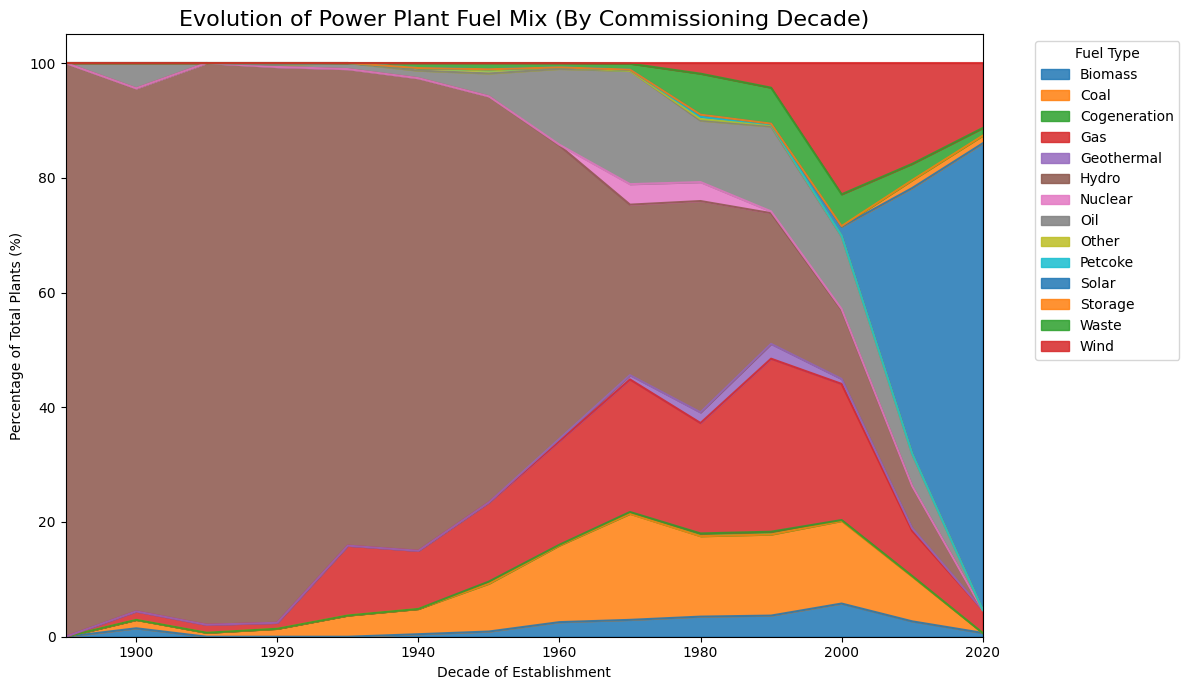

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the percentage evolution
evolution_pct.plot(kind='area', stacked=True, figsize=(12, 7),  alpha=0.85)

plt.title('Evolution of Power Plant Fuel Mix (By Commissioning Decade)', fontsize=16)
plt.ylabel('Percentage of Total Plants (%)')
plt.xlabel('Decade of Establishment')
plt.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.margins(0, 0) # Remove white space at edges
plt.tight_layout()
plt.show()

In [75]:
# We can see that the mix of power plant fuel types has changed significantly over the years, with hydro plants originally being a huge proportion of the power plants whereas towards today solar is a huge proportion of power plants. How about looking at total power generation capacity change over time?
# 1. Create a clean subset with capacity
df_cap = df[['primary_fuel', 'commissioning_year', 'capacity_mw']].dropna()

# 2. Group by year and fuel, summing the capacity
yearly_cap = df_cap.groupby(['commissioning_year', 'primary_fuel'])['capacity_mw'].sum().unstack(fill_value=0)

# 3. Calculate Cumulative Sum across the years (rows)
cumulative_cap = yearly_cap.cumsum()

print("Cumulative Capacity (MW) Preview:")
print(cumulative_cap.tail())

Cumulative Capacity (MW) Preview:
primary_fuel          Biomass         Coal  Cogeneration           Gas  \
commissioning_year                                                       
2019.000000         20710.611  1722337.261        1042.0  964134.49696   
2019.000000         20710.611  1722337.261        1042.0  964134.49696   
2019.411765         20710.611  1722337.261        1042.0  964134.49696   
2019.796326         20710.611  1722337.261        1042.0  964134.49696   
2020.000000         20713.411  1722337.261        1042.0  965405.89696   

primary_fuel        Geothermal        Hydro    Nuclear           Oil    Other  \
commissioning_year                                                              
2019.000000             7435.5  604220.0829  155062.96  123460.69014  2690.86   
2019.000000             7435.5  604220.0829  155062.96  123483.09014  2690.86   
2019.411765             7435.5  604220.0829  155062.96  123483.09014  2690.86   
2019.796326             7435.5  604220.082

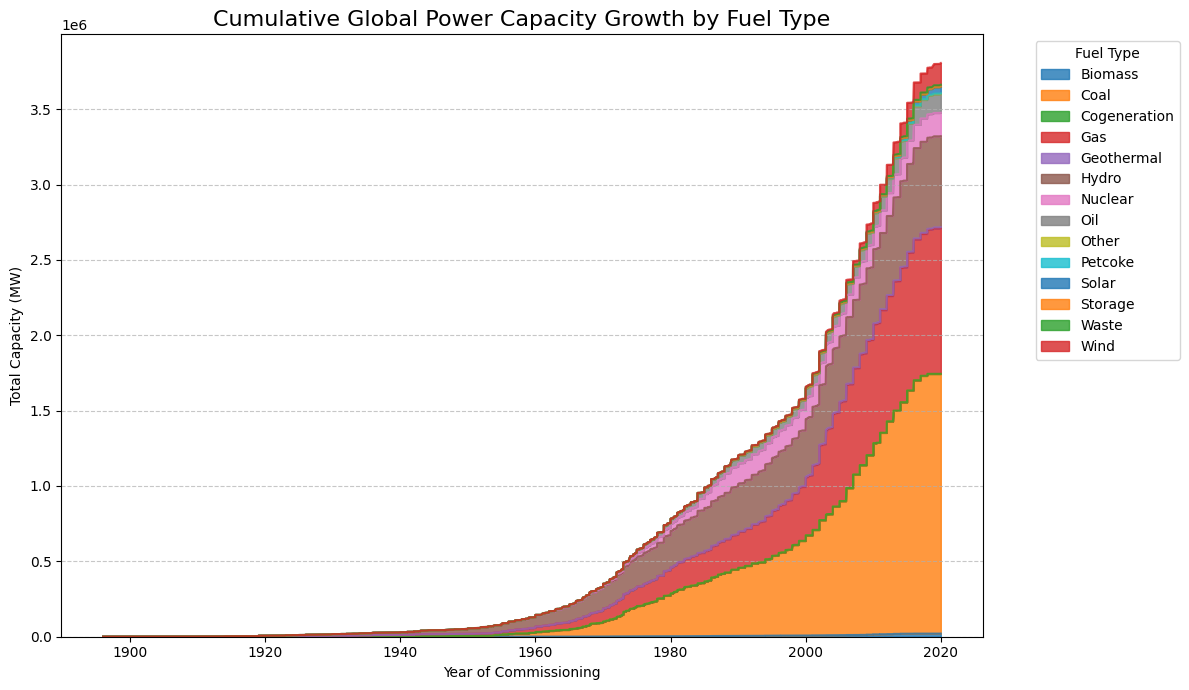

In [80]:
plt.figure(figsize=(12, 7))

# Plotting the absolute growth of capacity
cumulative_cap.plot(kind='area', stacked=True, alpha=0.8, ax=plt.gca())

plt.title('Cumulative Global Power Capacity Growth by Fuel Type', fontsize=16)
plt.ylabel('Total Capacity (MW)')
plt.xlabel('Year of Commissioning')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [81]:
# Here we see that whereas hydro power was initially the greatest source of power capacity, over time it has been overtaken by coal, and today coal, gas, and hyrdo are the greatest power capacity fuel types.

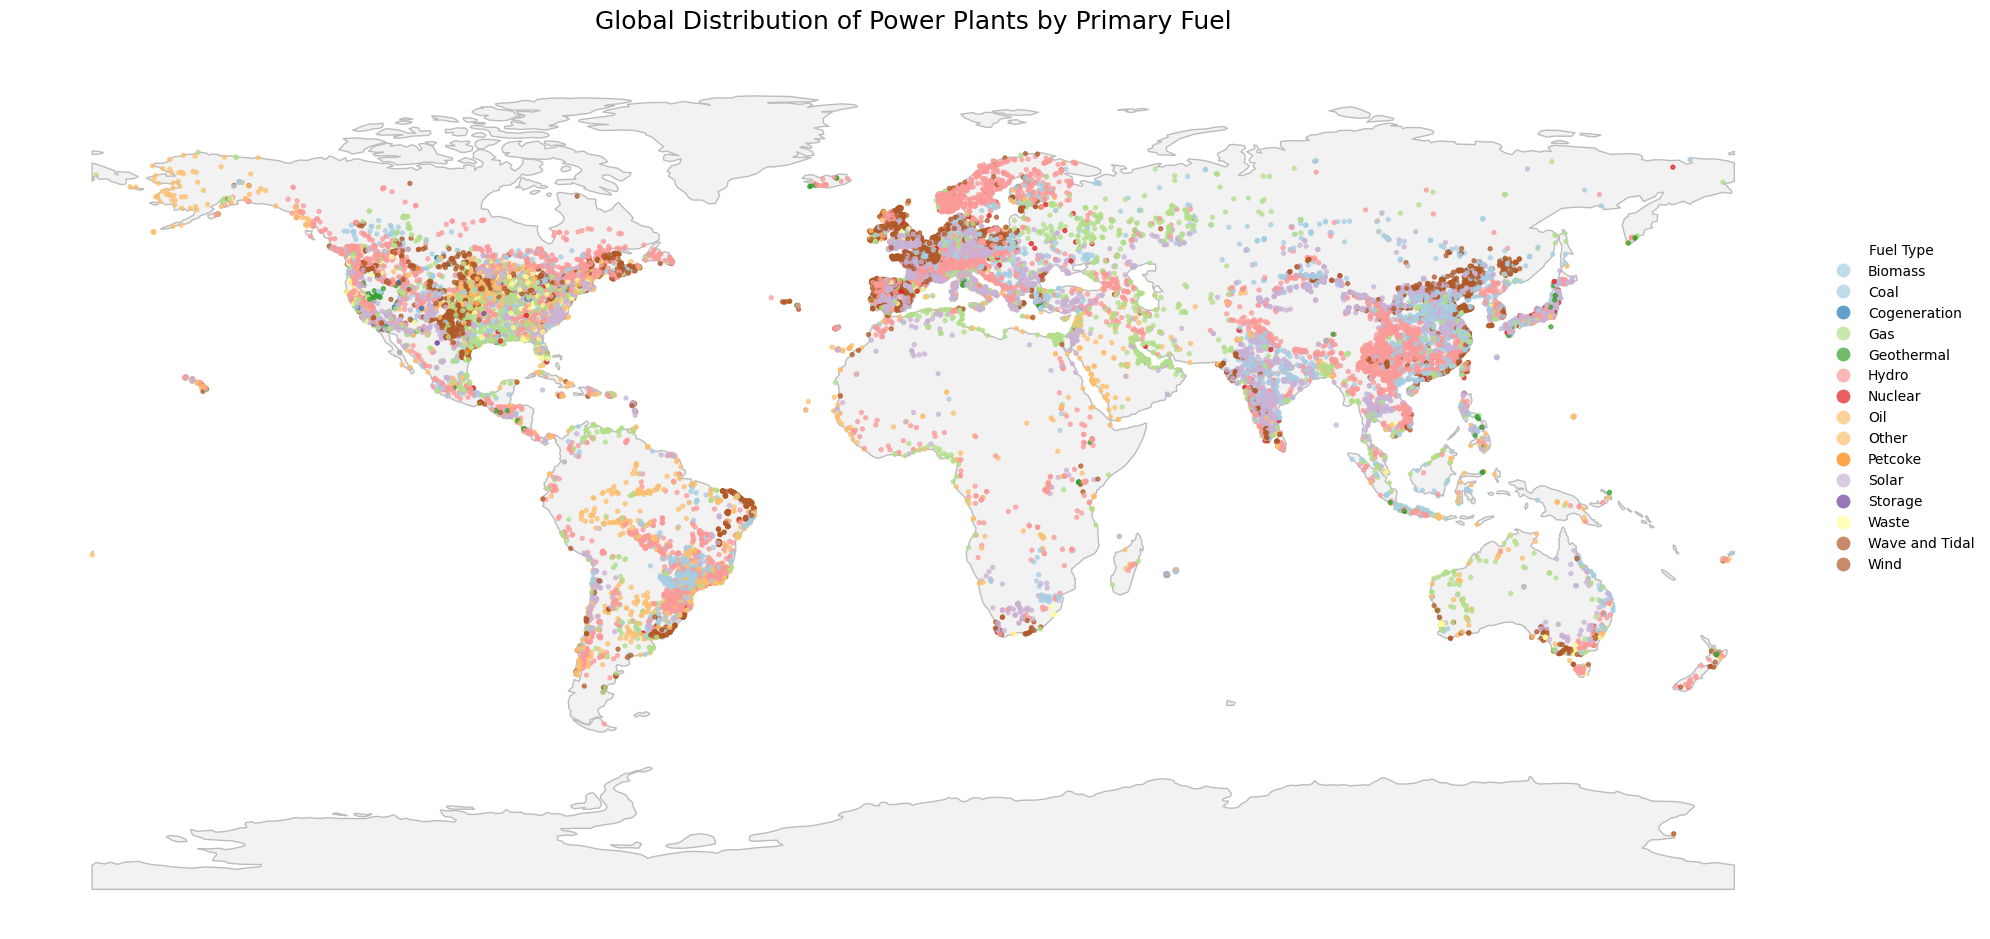

In [97]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from geodatasets import get_path # Required for modern GeoPandas datasets

# 1. Prepare your Power Plant Data
# (Assuming 'df' is your original DataFrame with 'latitude' and 'longitude')
gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"
)

# 2. Load the World Map (The New Way)
# Using 'naturalearth.land' for a clean base map
world_path = get_path("naturalearth.land")
world_map = gpd.read_file(world_path)

# 3. Create the Visualization
fig, ax = plt.subplots(figsize=(20, 10))

# Layer 1: The World Map (Base)
world_map.plot(ax=ax, facecolor='#f2f2f2', edgecolor='#bcbcbc', zorder=1)

# Layer 2: The Power Plants (Points)
# We use 'Paired' for distinct colors between fuel types
gdf.plot(
    ax=ax, 
    column='primary_fuel', 
    cmap='Paired', 
    markersize=8, 
    alpha=0.7, 
    legend=True,
    legend_kwds={
        'title': 'Fuel Type',
        'bbox_to_anchor': (1, 0.8),
        'loc': 'upper left',
        'fontsize': 10,
        'frameon': False
    },
    zorder=2
)

# 4. Final Formatting
plt.title('Global Distribution of Power Plants by Primary Fuel', fontsize=18, pad=20)
plt.axis('off') # Hides the lat/lon grid for a cleaner aesthetic

# Use tight_layout to ensure the legend isn't cut off
plt.tight_layout()


plt.show()

In [99]:
# Matrix Operations in Real-World Context:

#     Demonstrate matrix operations by analyzing relationships between different attributes (e.g., fuel type, capacity, and geographic location).
# To perform math on "Fuel Type," we first convert it into numbers using One-Hot Encoding.
# 1. Create a Feature Matrix (X)
# Columns: [Capacity, Latitude, Longitude, Is_Coal, Is_Solar, Is_Hydro]
fuel_dummies = pd.get_dummies(df['primary_fuel']).astype(int)
features = df[['capacity_mw', 'latitude', 'longitude']]

# Combine into a single NumPy Matrix
X = np.hstack([features.values, fuel_dummies.values])

print(f"Matrix Shape: {X.shape}") # (Rows, Features)

Matrix Shape: (34936, 18)


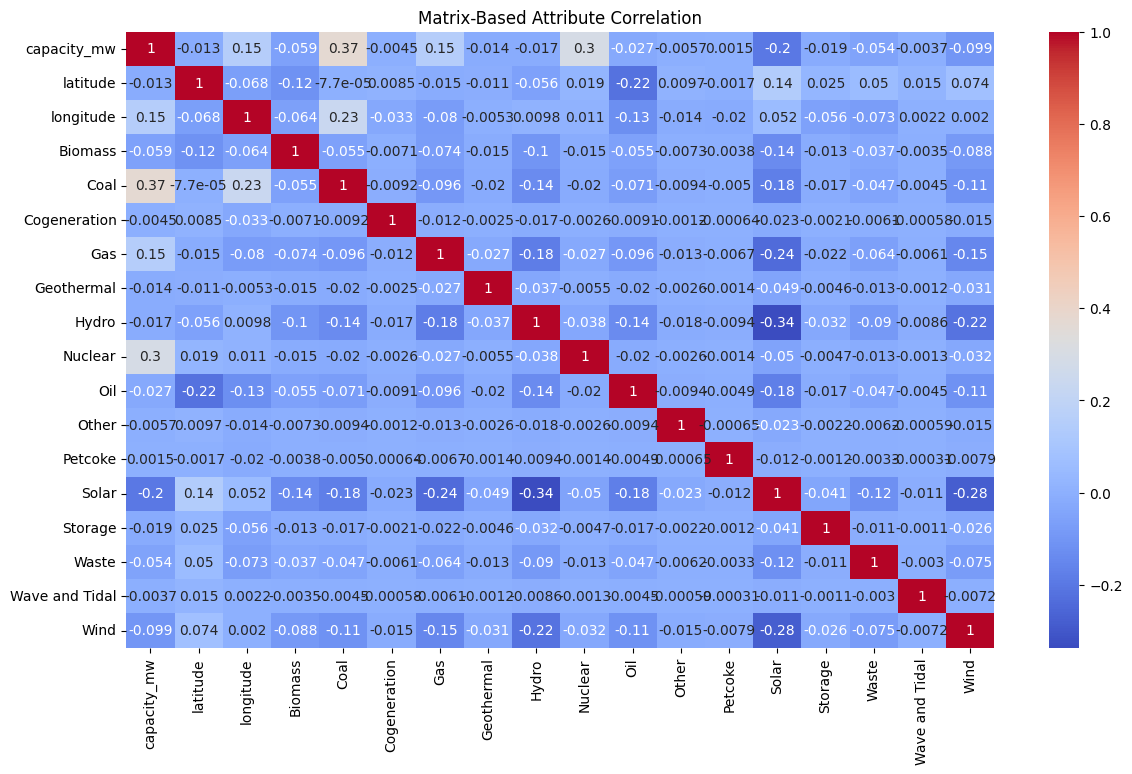

In [102]:
#To create a correlation matrix:
# Standardize the data (subtract mean, divide by std)
X_std = (X - X.mean(axis=0)) / X.std(axis=0)

# Matrix Multiplication: X_transpose * X
corr_matrix = (X_std.T @ X_std) / (X_std.shape[0] - 1)

# Visualize with Seaborn

plt.figure(figsize=(14, 8))
sns.heatmap(corr_matrix, annot=True, xticklabels=list(features.columns) + list(fuel_dummies.columns), 
            yticklabels=list(features.columns) + list(fuel_dummies.columns), cmap='coolwarm')
plt.title("Matrix-Based Attribute Correlation")
plt.show()

In [104]:
#In the context of the power plant dataset, Eigenvectors and Eigenvalues are the mathematical engines used to find the hidden structure of the global energy grid. With multiple variables (Capacity, Latitude, Longitude, and Year), they often overlap or correlate.
#Eigenvectors represent the "Principal Components" (directions). For example, one eigenvector might point in a direction that combines high capacity_mw with older commissioning_year, representing "Legacy Industrial Hubs."
# Eigenvalues represent the magnitude or "strength" of each direction. A large eigenvalue tells you that a lot of the variation in your dataset is explained by that specific eigenvector.
# We could use them to identify dominant trends, detect anomalies, and compress data.

In [105]:
# Integrating NumPy with Pandas and Matplotlib:

#     Show how NumPy can be used to enhance data manipulation in Pandas and data visualization in Matplotlib.
#     Provide examples, such as using NumPy arrays for complex filtering in Pandas or for creating sophisticated plots in Matplotlib.


In [108]:
#Complex Filtering with NumPy Logic:
# For multiple conditions, using NumPy’s logical functions (np.logical_and, np.isin) is often more readable and computationally efficient than chaining & symbols in Pandas.

# 1. Calculate a dynamic statistical threshold
capacity_75th = np.percentile(df['capacity_mw'].dropna(), 75)

# 2. Define complex logic masks using NumPy
is_large_scale = df['capacity_mw'] > capacity_75th
is_intermittent = np.isin(df['primary_fuel'], ['Solar', 'Wind'])
is_modern = df['commissioning_year'] > 2010

# 3. Combine using np.logical functions
# This is much cleaner for building complex business rules
final_mask = np.logical_and(np.logical_and(is_large_scale, is_intermittent), is_modern)

df_top_tier = df[final_mask]
df_top_tier

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
1072,BEL,Belgium,Northwind,WRI1002260,216.00,51.6186,2.8998,Wind,NaN,NaN,...,NaN,886.20,911.83,834.85,791.07,NO-ESTIMATION,WIND-V1,WIND-V1,WIND-V1,WIND-V1
1084,BEL,Belgium,Thorntonbank - C-Power - Area SW,WRI1002274,177.60,51.5400,2.9210,Wind,NaN,NaN,...,NaN,741.96,772.53,706.42,669.21,NO-ESTIMATION,WIND-V1,WIND-V1,WIND-V1,WIND-V1
1204,BRA,Brazil,Alegria II,BRA0028443,100.65,-5.1243,-36.3833,Wind,NaN,NaN,...,435.32,413.19,386.02,383.89,369.97,WIND-V1,WIND-V1,WIND-V1,WIND-V1,WIND-V1
7249,CHN,China,Kunming Shilin,WRI1029337,100.00,24.7800,103.4300,Solar,NaN,NaN,...,221.66,213.13,209.64,189.10,181.06,SOLAR-V1,SOLAR-V1,SOLAR-V1,SOLAR-V1,SOLAR-V1
9898,DNK,Denmark,Anholt,WRI1022033,399.60,56.6030,11.2090,Wind,NaN,NaN,...,NaN,1542.04,1550.15,1500.04,1359.44,NO-ESTIMATION,WIND-V1,WIND-V1,WIND-V1,WIND-V1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34343,USA,United States of America,Willow Springs Wind Farm,USA0060901,250.00,33.3454,-99.6243,Wind,NaN,NaN,...,NaN,NaN,NaN,NaN,734.18,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1
34379,USA,United States of America,Windstar 1,USA0057774,120.00,35.0542,-118.3547,Wind,NaN,NaN,...,352.42,357.71,323.92,322.50,320.25,WIND-V1,WIND-V1,WIND-V1,WIND-V1,WIND-V1
34407,USA,United States of America,Wistaria Ranch Solar,USA0061750,106.70,32.6760,-115.6190,Solar,NaN,NaN,...,NaN,NaN,NaN,NaN,173.87,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1
34461,USA,United States of America,Wright Solar Park,USA0059525,200.00,37.0094,-120.9572,Solar,NaN,NaN,...,NaN,NaN,NaN,NaN,325.90,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1


In [110]:
#Fast "If-Then-Else" with np.select, which processes entire columns as vectorized arrays:
# Define conditions and corresponding choices
conditions = [
    (df['primary_fuel'] == 'Coal') | (df['primary_fuel'] == 'Gas'),
    (df['primary_fuel'] == 'Solar') | (df['primary_fuel'] == 'Wind'),
    (df['primary_fuel'] == 'Hydro') | (df['primary_fuel'] == 'Nuclear')
]
categories = ['Thermal', 'Variable Renewable', 'Stable Low-Carbon']

# Create a new column instantly
df['energy_type'] = np.select(conditions, categories, default='Other')

Text(0.5, 1.0, 'Global Energy Density (Calculated via NumPy)')

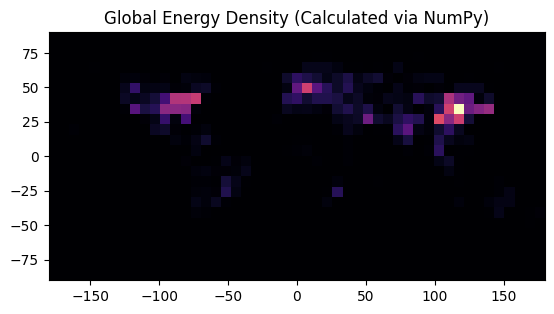

In [112]:
# Sophisticated Visualization with NumPy
# NumPy allows us to transform raw data points into higher-level mathematical structures, like Density Grids or Trend Lines, which tell a much deeper story than a standard scatter plot.
# A. High-Performance Density Grids (np.histogram2d)
# Instead of plotting 30,000 overlapping dots (which makes the map unreadable), we use np.histogram2d to calculate a 2D intensity grid of the world's power capacity.
# 1. Bin coordinates into a 50x25 grid
lon_bins = np.linspace(-180, 180, 50)
lat_bins = np.linspace(-90, 90, 25)

# 2. Use NumPy to sum capacity (weights) for every grid cell
density, x_edges, y_edges = np.histogram2d(
    df['longitude'], df['latitude'], 
    bins=[lon_bins, lat_bins], 
    weights=df['capacity_mw']
)

# 3. Plot as a smooth heatmap
plt.imshow(density.T, extent=[-180, 180, -90, 90], cmap='magma', origin='lower')
plt.title("Global Energy Density (Calculated via NumPy)")

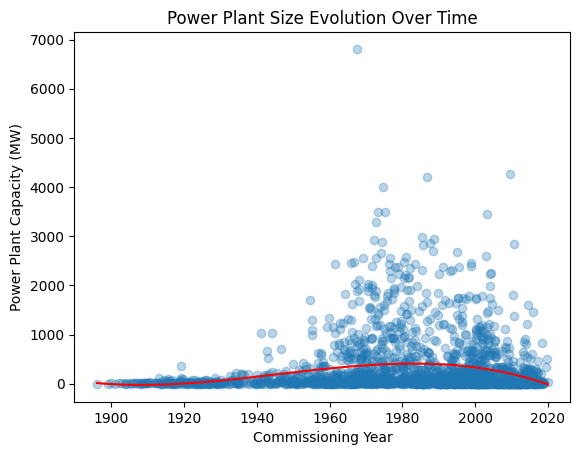

In [115]:
# B. Trend Modeling with np.polyfit
# If we want to know if power plants are getting larger or smaller over time, you can use NumPy to fit a Polynomial Trend Line through the noise of thousands of individual commissioning years.
# Calculate yearly means
yearly = df.groupby('commissioning_year')['capacity_mw'].mean().dropna()
years, capacities = yearly.index.values, yearly.values

# Use NumPy to find a 3rd-degree polynomial trend line
coefficients = np.polyfit(years, capacities, 3)
trend_model = np.poly1d(coefficients)
x_range = np.linspace(years.min(), years.max(), 100)

# Plotting the model over the raw data
plt.title('Power Plant Size Evolution Over Time')
plt.xlabel('Commissioning Year')
plt.ylabel('Power Plant Capacity (MW)')
plt.scatter(years, capacities, alpha=0.3)
plt.plot(x_range, trend_model(x_range), color='red', label='Polynomial Trend')
plt.show()